# Project card

**The paper:** 

>Volatility of Mutator Phenotypes at Single
Cell Resolution

**The data object:**

>Novel mutation count per cell division for all lineages

**The random variable chosen:**

>Mutation count

**What the paper does:**

>Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**

> monte carlo with 1-poisson model 

> monte carlo with 2-poisson model https://link.springer.com/rwe/10.1007/978-0-387-39940-9_920

**Parameters and assumptions:**

> 1-Poisson

    -Assumptions: Events occur independently of each other, the rate at which events occur is constant over time or space, two events cannot occur at exactly the same instant and the mean and the variance of the distribution are equal.

    -Parameter: λ (lambda), the average rate or expected number of events per unit of time or space.

> 2-Poisson

    -Assumptions: The data comes from two distinct subpopulations, each generating events independently, each subpopulation follows its own Poisson distribution with its own constant rate, each observation belongs to one of the two subpopulations governed by a mixing proportion and the two Poisson processes are independent of each other.

    -Parameters: λ₁ (lambda1), the average rate of the first Poisson component; λ₂ (lambda2), the average rate of the second Poisson component; and π (pi), the mixing proportion, representing the probability that an observation belongs to the first component (with 1−π belonging to the second).

**The forward simulation:**

> Monte-Carlo simulation

**The parameterization/fitting:**

> Grid search to find parameters for 1 poisson

> Grid search to find parameters for 2 poisson

**What/if the model adds to the paper:**

 >It confirms that 2 poisson is a better fit for the data than 1 poisson

 > The parameters obtained using 2 poisson model are close to the reported values 

**Model limitations/how it breaks:**
> 1 poisson variance is much higher than the mean. its overdispersed

> The Poisson assumptions may not be perfectly satisfied biologically: mutation events may not be completely independent and mutation rates may vary between divisions. In addition, the mixture model does not prove that exactly two discrete biological populations exist; it is a simplified mechanistic model that explains the observed heterogeneity. Therefore, the estimated parameters should be interpreted as model-based estimates rather than exact biological quantities.

---

## Utils

### Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize

### Functions

In [2]:
def mean(counts):
    """The mean of a list of counts."""
    return sum(counts) / len(counts)

def std_dev(counts):
    """The standard deviation of a list of counts."""
    m = mean(counts)
    total = 0.0
    for x in counts:
        total = total + (x - m) ** 2
    return math.sqrt(total / len(counts))

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)

def two_poisson(x, alpha, theta, delta):
    return (alpha * poisson(x, theta)) + ((1-alpha) * poisson(x, delta))

def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total

def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total

def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

def nll_mix_poisson(parameters, counts):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    mu1, mu2, pi = parameters[0], parameters[1], parameters[2]
    total = 0.0
    for x in counts:
        prob = max(pi * poisson(x, mu1) + (1 - pi) * poisson(x, mu2), 1e-10)  # Avoid log(0)
        total = total - math.log(prob)
    return total

# Do something with unused variable
def fit_2_poisson(counts, mu1, mu2, pi):
    flag = True
    for k in pi:
        for j in mu2:
            for i in mu1:
                total = 0
                for m in range(len(lineages)):
                    total += nll_mix_poisson([i*(genome_size_lineages[m])*10**(-7), j*(genome_size_lineages[m])*10**(-7), k], lineages[m])
                nll_mix_poisson_score = total
                if flag:
                    minimum = nll_mix_poisson_score
                    mu1_hat = i
                    mu2_hat = j
                    pi_hat = k
                    flag = False
                elif nll_mix_poisson_score < minimum:
                    minimum = nll_mix_poisson_score
                    mu1_hat = i
                    mu2_hat = j
                    pi_hat = k
                    
    return round(mu1_hat, 3), round(mu2_hat, 3), round(pi_hat, 3)

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32
seed = 100

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out

def choose(r, probs):
    """The outcome k whose slice of [0, 1) contains r, the slices laid end to end in order. Returns k as a position in probs, from 0."""
    running = 0.0
    for k in range(len(probs)):
        running = running + probs[k]
        if r < running:
            return k
    return len(probs) - 1

def fraction_zero(counts):
    """p0, the fraction of cultures with no resistant colonies at all."""
    empty = 0
    for c in counts:
        if c == 0:
            empty = empty + 1
    return empty / len(counts)

def simuate_count_oneP(lam, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = poisson(0, lam)
    k = 0
    while r > total:
        k += 1
        total = total + poisson(k, lam)
    return k, state

def experiment_oneP(lam, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simuate_count_oneP(lam, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

def simuate_count_twoP(alpha, lam, delta, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = two_poisson(0, alpha, lam, delta)
    k = 0
    while r > total:
        k += 1
        total = total + two_poisson(k, alpha, lam, delta)
    return k, state

def experiment_twoP(alpha, lam, delta, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simuate_count_twoP(alpha, lam, delta, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

## Main

## Reported Values

In [3]:
rprt_one_poisson_lambda = 2.652
rprt_two_poisson_lambda_low = 0.402
rprt_two_poisson_lambda_high = 3.897

genome_size = int(1.02E+07)
genome_size_lineages = [10926041,10034503,10099122,10889177,11040018,9684038,10209723,10826564]

### 1. Read Files

In [4]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna().astype(int)) for column in df.columns]
counts = [int(y) for x in lineages for y in x]

print("Data Matrix:")
print(df,"\n")
print("Lineage Cell Division Counts:")
print("\n".join(str(lin) for lin in lineages), "\n")

Data Matrix:
           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN 

Lineage Cell Division Counts:
[0, 2, 0, 3, 2, 4, 1, 3, 4]
[3, 7, 6, 0, 0, 2, 3, 4, 4, 6, 5, 1, 0]
[2, 2, 0, 3, 0, 0, 1, 1, 4, 5, 3, 0, 9, 4, 2]
[2, 3, 1

### 2. Summary Statistics

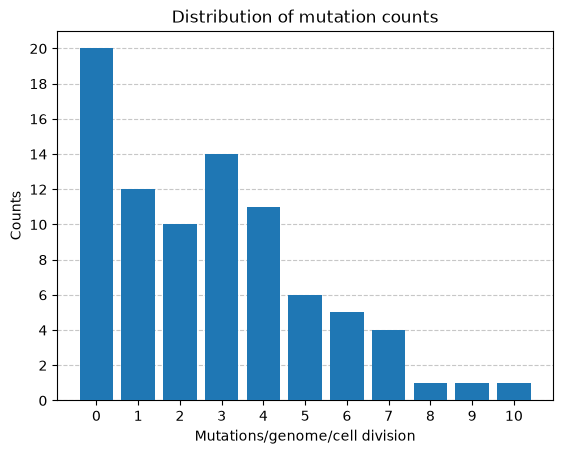

In [5]:
max_mutation_count = max(counts)
mutation_counts = [0] * (max_mutation_count + 1)

for count in counts:
    mutation_counts[count] += 1 

mean_count = mean(counts)
sigma = std_dev(counts)
rprt_variance = sigma ** 2
rprt_zeros = counts.count(0)
mutation_rate = mean_count/genome_size
# mutation_prob =  [ mutation_count/sum(mutation_counts) for mutation_count in mutation_counts ]

fig, ax = plt.subplots()
ax.bar(range(len(mutation_counts)), mutation_counts, zorder=3)
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Counts")
ax.set_xticks(range(0,11))
ax.set_yticks(range(0,22,2))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.set_title("Distribution of mutation counts")
plt.show()

#### Mean and Variance of Paper's Data

In [6]:
print(f"Mean: {mean_count} mutations/cell division")
print(f"Mean: {mutation_rate} mutations/cell division/bp for average genome size of {genome_size}")
print(f"Standard Deviation: {sigma}")
print(f"Variance: {rprt_variance}")
print(f"Number of zeros: {rprt_zeros}")
print("Variance is higher than mean, thus overdispersed")


Mean: 2.7411764705882353 mutations/cell division
Mean: 2.6874279123414073e-07 mutations/cell division/bp for average genome size of 10200000
Standard Deviation: 2.3919125558306864
Variance: 5.721245674740486
Number of zeros: 20
Variance is higher than mean, thus overdispersed


### 3. Models

#### 3.1. 1-Poisson Model

##### 3.1 Forwards Simulation - Monte-Carlo Simulation

σ² (Simulation): 2.6401533746976447 (mutations/cell division/bp)² 
σ² (Reported Data): 5.721245674740486 (mutations/cell division/bp)²
Zero Count (Simulation) 6.29 
Zero Count (Reported Data) 20


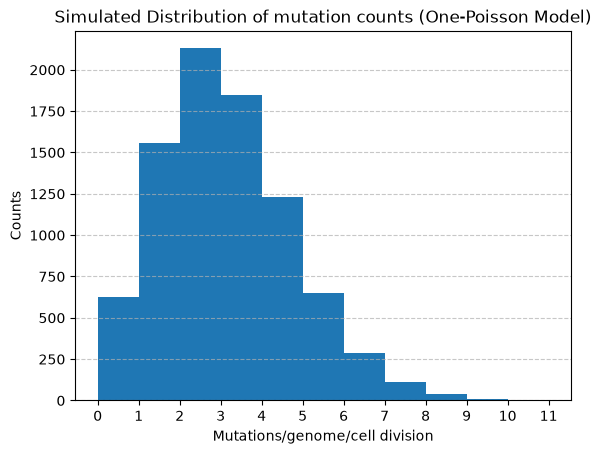

In [26]:
cell_divisions = 85
state = seed

simulated_runs_oneP = []
sim_oneP_devs = []
sim_oneP_zeros = []
sim_oneP_sums = []

for i in range(100):
    simulated_counts, state = experiment_oneP(rprt_one_poisson_lambda, cell_divisions, state)
    simulated_runs_oneP.append(simulated_counts)
    sim_oneP_devs.append(std_dev(simulated_counts))
    sim_oneP_zeros.append(fraction_zero(simulated_counts) * 85)
    

print(f"σ² (Simulation): {mean(sim_oneP_devs) ** 2} (mutations/cell division/bp)² \nσ² (Reported Data): {rprt_variance} (mutations/cell division/bp)²")
print(f"Zero Count (Simulation) {mean(sim_oneP_zeros)} \nZero Count (Reported Data) {rprt_zeros}")

fig, ax = plt.subplots()
simulated_runs_oneP_flat = [y for x in simulated_runs_oneP for y in x]
ax.hist(simulated_runs_oneP_flat, bins=range(min(simulated_runs_oneP_flat), max(simulated_runs_oneP_flat)+1, 1))
ax.set_xticks((range(min(simulated_runs_oneP_flat), max(simulated_runs_oneP_flat)+1, 1)));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Simulated Distribution of mutation counts (One-Poisson Model)")
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.show()

#### 3.1.3 Backwards - estimating the 1-poisson model’s parameter/s

In [8]:
mu_candidates = np.arange(0.02, 5, 0.02).tolist()            

scores_nll_ = [0.0] * len(mu_candidates)

for i in range(len(mu_candidates)):
  total = 0
  for j in range(len(lineages)):
    total += nll(lineages[j], mu_candidates[i]*(genome_size_lineages[j])*10**(-7))
  scores_nll_[i] = total

position_of_min_nll = position_of_min(scores_nll_)
mu_hat = mu_candidates[position_of_min_nll]
print(f"Estimated mutation rate (mu_hat): {mu_hat} e-7 mutations/bp/cell division")
print(f"Reported mutation rate:  2.6 e-7 mutations/bp/cell division")

Estimated mutation rate (mu_hat): 2.62 e-7 mutations/bp/cell division
Reported mutation rate:  2.6 e-7 mutations/bp/cell division


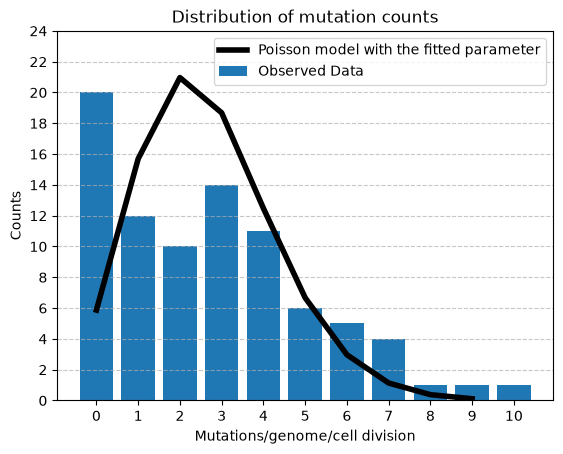

In [9]:
k_counts = range(max_mutation_count)
y = [0] * len(k_counts)
for i in range(len(k_counts)):
    y[i] += poisson(k_counts[i], mu_hat*genome_size*10**(-7))

y = [n * 85 for n in y]
plt.plot(k_counts, y,color="black", label="Poisson model with the fitted parameter",linewidth=4)
plt.bar(range(len(mutation_counts)), mutation_counts, label="Observed Data")
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11))
plt.yticks(range(0,25,2))
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

### 3.2 Monte Carlo for 2-Poisson Model 

##### 3.2 Forwards Simulation - Monte-Carlo Simulation

σ² (Simulation): 5.4193034345451006 (mutations/cell division/bp)² 
σ² (Reported Data): 5.721245674740486 (mutations/cell division/bp)²
Zero Count (Simulation) 21.09 
Zero Count (Reporteed Data) 20


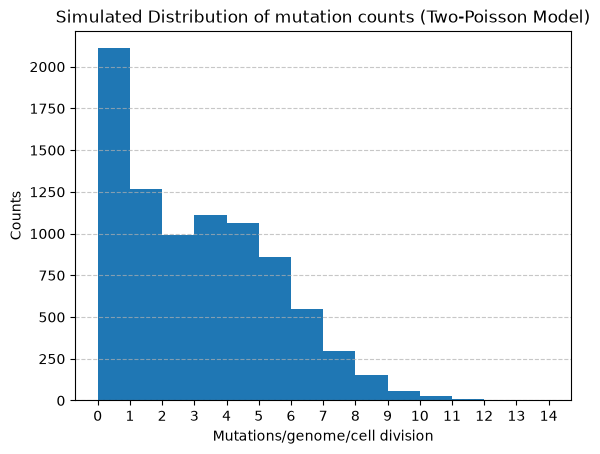

In [27]:
cell_divisions = 85
state = seed

simulated_runs_twoP = []
sim_twoP_devs = []
sim_twoP_zeros = []
sim_twoP_sums = []

for i in range(100):
    simulated_counts, state = experiment_twoP(0.35, 0.402, 3.897, cell_divisions, state)
    simulated_runs_twoP.append(simulated_counts)
    sim_twoP_devs.append(std_dev(simulated_counts))
    sim_twoP_zeros.append(fraction_zero(simulated_counts) * 85)
    sim_twoP_sums.append(sum(simulated_counts))

print(f"σ² (Simulation): {mean(sim_twoP_devs) ** 2} (mutations/cell division/bp)² \nσ² (Reported Data): {rprt_variance} (mutations/cell division/bp)²")
# print(mean(sim_twoP_devs))
print(f"Zero Count (Simulation) {mean(sim_twoP_zeros)} \nZero Count (Reporteed Data) {rprt_zeros}")

fig, ax = plt.subplots()
simulated_runs_twoP_flat = [y for x in simulated_runs_twoP for y in x]
ax.hist(simulated_runs_twoP_flat, bins=range(min(simulated_runs_twoP_flat), max(simulated_runs_twoP_flat)+1, 1))
ax.set_xticks((range(min(simulated_runs_twoP_flat), max(simulated_runs_twoP_flat)+1, 1)));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Simulated Distribution of mutation counts (Two-Poisson Model)")
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.show()

#### 2-Poisson Model Backwards estimate

In [22]:
mu1_candidates = np.arange(0, 2, 0.02).tolist()
mu2_candidates = np.arange(1 , 5, 0.02).tolist()
pi_candidates = np.arange(0.05 , 0.95, 0.05).tolist()

mu1_hat, mu2_hat, pi_hat = fit_2_poisson(counts, mu1_candidates, mu2_candidates, pi_candidates)

reported_mu1 = 0.4e-7
reported_mu2 = 4.0e-7
reported_pi = 35.0
header_format = "{:<15} | {:>20} | {:>20}"
row_format = "{:<15} | {:>20} | {:>20}"

print("-" * 61)
print(header_format.format("Parameter", "Estimated Value", "Reported Value"))
print("-" * 61)
print(row_format.format("mu1", f"{mu1_hat*10}e-08", f"{reported_mu1}"))
print(row_format.format("mu2", f"{mu2_hat}e-07", f"{reported_mu2}"))
print(row_format.format("pi", f"{pi_hat*100}%", f"{reported_pi}%"))
print("-" * 61)

-------------------------------------------------------------
Parameter       |      Estimated Value |       Reported Value
-------------------------------------------------------------
mu1             |              4.4e-08 |                4e-08
mu2             |              3.8e-07 |                4e-07
pi              |                35.0% |                35.0%
-------------------------------------------------------------


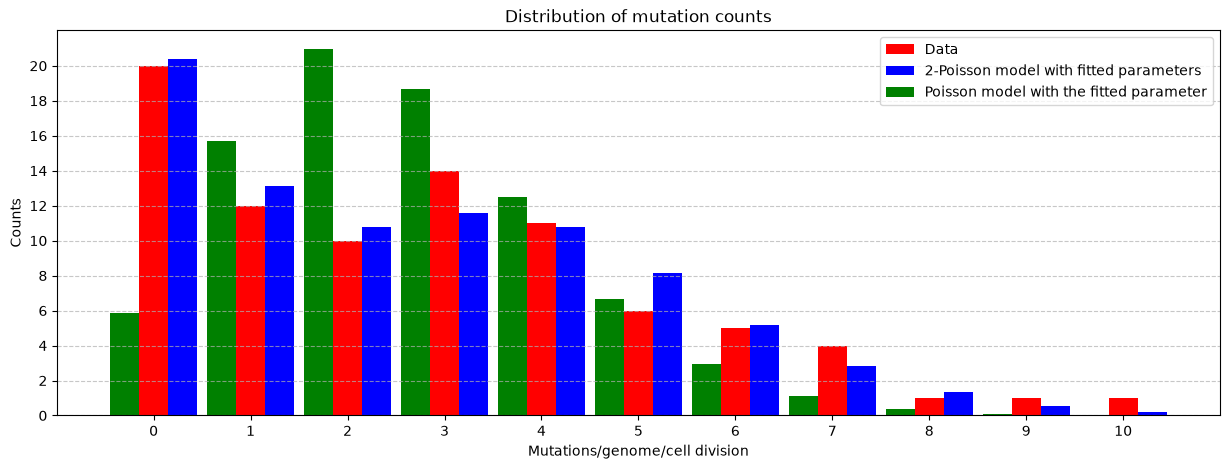

In [ ]:
y_mix_poisson_lik = [0] * len(counts)
y_mix_poisson_test = [0] * len(counts)

for i in range(len(counts)):
    y_mix_poisson_lik[i] += pi_hat * poisson(counts[i], mu1_hat) + (1-pi_hat) * poisson(counts[i], mu2_hat)
    y_mix_poisson_test[i] += 0.35 * poisson(counts[i], 0.5) + (1-0.35) * poisson(counts[i], 3.5)

N = 85
y_mix_poisson_lik = [x*N for x in y_mix_poisson_lik]
y_mix_poisson_test = [x*N for x in y_mix_poisson_test]

plt.figure(figsize=(15, 5))
plt.bar(np.array(range((max_mutation_count)+1)), mutation_counts, width=0.3, label='Data', color='red')
plt.bar(np.array(counts) + 0.3, y_mix_poisson_lik, width=0.3, label='2-Poisson model with fitted parameters', color='blue')
plt.bar(np.array(k_counts) - 0.3, y,color="green", label="Poisson model with the fitted parameter", width=0.3)
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

### Comparing models with AIC

In [13]:
AIC_1_Poisson = 2 * 1 + 2 * scores_nll_[position_of_min_nll]
AIC_2_Poisson = 2 * 3 + 2 * nll_mix_poisson([mu1_hat, mu2_hat, pi_hat], counts)
print("AIC for 1-Poisson model:", round(AIC_1_Poisson,2))
print("AIC for 2-Poisson model:", round(AIC_2_Poisson,2))

AIC for 1-Poisson model: 402.12
AIC for 2-Poisson model: 364.22


### Parameter uncertainty

Liklihood Interval

> How to do for 2 poisson?

#### Curvature error bar

In [14]:
result = minimize(nll_mix_poisson, [mu1_hat, mu2_hat, pi_hat], args=(counts,), method='BFGS')

if result.success:
    best_parameters = result.x

    #'hess_inv' is the inverse of the Hessian (Covariance Matrix)
    covariance_matrix = result.hess_inv

    #The square roots of the diagonal are the Standard Errors (uncertainty)
    standard_errors = np.sqrt(np.diag(covariance_matrix))

    print("--- FINAL OPTIMIZED RESULTS ---")
    print(f"mu_1 (i): {best_parameters[0]:.4f} (Uncertainty: ±{standard_errors[0]:.4f})")
    print(f"mu_2 (j): {best_parameters[1]:.4f} (Uncertainty: ±{standard_errors[1]:.4f})")
    print(f"proportion pi (k): {best_parameters[2]:.4f} (Uncertainty: ±{standard_errors[2]:.4f})")
else:
    print("The optimizer could not refine the parameters. Check whether your initial data is well written.")

--- FINAL OPTIMIZED RESULTS ---
mu_1 (i): 0.4019 (Uncertainty: ±0.2380)
mu_2 (j): 3.8967 (Uncertainty: ±0.3503)
proportion pi (k): 0.3306 (Uncertainty: ±0.0803)


#### Bootstrap method

In [ ]:
B = 2000
SEED = 26546
rs = uniforms(B * N, SEED)
equal = [1 / N] * N

boot_estimates = [0.0] * B
for b in range(B):
  resample = [0.0] * N
  for i in range(N):
    j = choose(rs[b*N + i], equal)
    resample[i] = counts[j]
    boot_estimates[b] = mean(resample)

sigma_boot = std_dev(boot_estimates)
print(f"Bootstrap estimate of standard error: {round(sigma_boot, 3)} mutations/genome/cell division")

Bootstrap estimate of standard error: 0.254 mutations/genome/cell division


### Discussion

- The Poisson model is biologically plausible because it describes the number of rare mutation events occurring during a fixed cell division. Each cell division is one observation and the number of newly fixed mutations is the random variable.

- A single Poisson assumes that all cell divisions have the same mutation rate. However, the data show strong overdispersion, meaning that the variability is larger than expected under a single Poisson distribution. The two-Poisson mixture provides a biological explanation for this heterogeneity by modelling two mutator phenotypes: a hypomutator population with a low mutation rate and a hypermutator population with a high mutation rate. Therefore, the mixture is not only a better-fitting curve but represents a plausible alternative mechanism for generating the observed data.

- The simulation results show that the two-Poisson model fits the reported data much better than the single Poisson model. For the variance (σ²), the single Poisson simulation produced a value of 2.64, which is far from the reported 5.72, while the Two-Poisson simulation yielded 5.42, much closer to the reported value. Similarly, the zero count in the single Poisson simulation was 6.29, far below the reported 20, whereas the Two-Poisson simulation gave 21.09, nearly matching the reported value.

- The two-Poisson model performed better than the single-Poisson model, with AIC values of 364.22 and 402.12, respectively. The lower AIC supports the additional complexity of the mixture model. The simulations also showed that the two-Poisson model reproduces the observed distribution more closely.

- The estimated mutation rates were approximately 4.4e-8 and 3.8e-7 mutations/bp/cell division, with 35% of observations assigned to the low-mutation population. These values are close to those reported in the paper: 4e-8 and 4e-7 mutations/bp/cell division and 35% for the hypomutator population. This agreement provides a useful check that our fitting procedure produces biologically consistent parameter estimates.

- Parameter uncertainty was explored using uncertainty estimates from the fitted models and by simulation. For the single-Poisson model, we used bootstrap resampling to estimate the uncertainty of the parameter because this model is known to be an incomplete description of the data. Bootstrap is appropriate here because it estimates variability directly from the observed data without requiring the single-Poisson model to be correct.